In [93]:
import pandas as pd
df_ABC3 = pd.read_csv("../ABC3_filtered.csv")
df_A2BCX6 = pd.read_csv("../A2BCX6_filtered.csv")


#Merge the two pervoskites data frames and treat them as one 
df = pd.concat([df_ABC3, df_A2BCX6], axis=0,ignore_index=True)
df.to_csv("df.csv", index=False) 
print(df)

/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/4252663068.py:2: DtypeWarning: Columns (64,334,436,534,540,570,602,608,614,620,690,696,704,710,716,722,728,772,778,784,790,796,802,808,814,834,846,858,870,896,902,908,914,920,960,966,972,978,992,998,1004,1010,1016,1022,1028,1034,1085,1086,1088,1089,1090,1092,1095,1096,1098,1099,1101,1102,1103,1105,1108,1109,1137,1138,1140,1141,1142,1143,1144,1147,1148,1150,1151,1153,1154,1155,1156,1157,1160,1161,1189,1190,1192,1193,1194,1196,1199,1200,1202,1203,1205,1206,1207,1209,1212,1213,1214,1220,1226,1232,1262,1268,1274,1280,1301,1302,1303,1304,1305,1306,1313,1314,1315,1316,1317,1318,1349,1350,1351,1352,1353,1354,1361,1362,1363,1364,1365,1366,1397,1398,1399,1400,1401,1402,1409,1410,1411,1412,1413,1414,1433,1439,1445,1451,1562,1564,1582,1583,1584,1585,1586,1587,1588,1589,1590,1591,1592,1593,1631,1632,1633,1634,1636,1637,1638,1639,1640,1641,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1

      nsites                 elements  nelements formula_pretty  \
0         20        ['Ag', 'Br', 'S']          3         Ag3SBr   
1          5         ['Ag', 'I', 'S']          3          Ag3SI   
2          5         ['Ag', 'I', 'S']          3          Ag3SI   
3        120        ['Ag', 'As', 'O']          3         AgAsO3   
4         20        ['Ag', 'Cl', 'O']          3         AgClO3   
...      ...                      ...        ...            ...   
1419      20  ['As', 'Bi', 'Mg', 'O']          4      Mg2BiAsO6   
1420      20   ['Bi', 'Mg', 'O', 'P']          4       Mg2BiPO6   
1421      60   ['C', 'Cl', 'Mg', 'O']          4       Mg2CClO6   
1422      20   ['Bi', 'Mg', 'O', 'V']          4       Mg2VBiO6   
1423      80  ['Fe', 'Mg', 'O', 'Si']          4    MgFe(SiO3)2   

     formula_anonymous     chemsys       volume   density  density_atomic  \
0                 ABC3     Ag-Br-S   484.805518  5.967646       24.240276   
1                 ABC3      Ag-I-S   121.

In [94]:

def get_data (df):
    df_curated = pd.DataFrame()
    df_curated["Elements"] = df["elements"]
    df_curated["band_gap"] = df["band_gap"]
    # df_curated["formula_pretty"] = df["formula_pretty"]
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None

    for i in range(df_curated.shape[0]):
        

        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
        # #cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")

        df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("'", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("[", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("]", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace(" ", "")


        # df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        # df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].strip("'")
    return df_curated



df_curated = get_data(df)
df_curated

# print(df_curated["structure_string"].iloc[1][2])
# print(df_curated["structure_string"].iloc[1][2])


/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/1062056243.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
/var/folders/k8/4c

,Elements,band_gap,structure_string,structure_string_split
0,"[Ag, Br, S]",0.2964,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.552885,..."
1,"[Ag, I, S]",0.5478,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.5259809..."
2,"[Ag, I, S]",0.6243,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.5, 0.5,..."
3,"[Ag, As, O]",0.5930,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.546128,..."
4,"[Ag, Cl, O]",2.3983,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.297407,..."
...,...,...,...,...
1419,"[As, Bi, Mg, O]",3.3424,"[{'species': [{'element': 'Mg', 'occu': 1}], '...","[species, element, Mg, occu, 1, abc, 0.711533,..."
1420,"[Bi, Mg, O, P]",3.6043,"[{'species': [{'element': 'Mg', 'occu': 1}], '...","[species, element, Mg, occu, 1, abc, 0.25, 0.9..."
1421,"[C, Cl, Mg, O]",0.0014,"[{'species': [{'element': 'Mg', 'occu': 1}], '...","[species, element, Mg, occu, 1, abc, 0.7534781..."
1422,"[Bi, Mg, O, V]",3.1885,"[{'species': [{'element': 'Mg', 'occu': 1}], '...","[species, element, Mg, occu, 1, abc, 0.3983569..."


In [95]:
def split_df (df):

    # each element has 18 entries in this split 
    df["positions"] = None
    for i in range(len(df["structure_string_split"])):
        position_i = []
        for j in range (0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][j+2] # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j+15])
            y = float(df["structure_string_split"].iloc[i][j+16])
            z = float(df["structure_string_split"].iloc[i][j+17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i
    return df


df_curated = split_df(df_curated)
df_curated.drop(columns=["structure_string", "structure_string_split"], inplace=True)
df_curated

/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/4137563856.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["positions"].iloc[i] = position_i
/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/4137563856

,Elements,band_gap,positions
0,"[Ag, Br, S]",0.2964,"[(Ag, [7.484018762358994, 2.1052739231579953, ..."
1,"[Ag, I, S]",0.5478,"[(Ag, [1.9446232162929962, -1.7475588302039966..."
2,"[Ag, I, S]",0.6243,"[(Ag, [2.504793, 2.504793, 0.0]), (Ag, [2.5047..."
3,"[Ag, As, O]",0.5930,"[(Ag, [3.6893780804319993, 8.095737138524, 12...."
4,"[Ag, Cl, O]",2.3983,"[(Ag, [-2.3547247593569416e-17, 2.354724759356..."
...,...,...,...
1419,"[As, Bi, Mg, O]",3.3424,"[(Mg, [6.438932173827999, 1.1529028821240004, ..."
1420,"[Bi, Mg, O, P]",3.6043,"[(Mg, [1.31771425, 5.857656804502336, 2.475580..."
1421,"[C, Cl, Mg, O]",0.0014,"[(Mg, [-4.8284888157376145, 2.4961544311419446..."
1422,"[Bi, Mg, O, V]",3.1885,"[(Mg, [2.4679847685779963, -1.1408018649349936..."


In [96]:
from collections import Counter

from collections import Counter
import numpy as np

def get_ratio(df):
    # Input: pd.datafram with a column "positions" containing lists of tuples (element, [x, y, z])
    #
    # Output: appends dataframe with a new column "ratio" containing a sorted dictionary of elements and their ratios
    #
    df["ratio"] = None

    #loops over all entriey in positions
    for i, atom_list in enumerate(df["positions"]):
        elements = [atom[0] for atom in atom_list]
        occurance = Counter(elements)

        counts = np.fromiter(occurance.values(), dtype=int)

        gcd = np.gcd.reduce(counts)


        reduced_occurance = {element: count // gcd for element, count in occurance.items()}

        # Sort by value so largest is last
        sorted_occurrence = dict(sorted(reduced_occurance.items(), key=lambda item: item[1]))

        df["ratio"].iloc[i] = sorted_occurrence

    return df

df_curated = get_ratio(df_curated)
print(df_curated.head(5))

df_curated.to_csv("df_curated.csv", index=False)
df_curated


      Elements  band_gap                                          positions  \
0  [Ag, Br, S]    0.2964  [(Ag, [7.484018762358994, 2.1052739231579953, ...   
1   [Ag, I, S]    0.5478  [(Ag, [1.9446232162929962, -1.7475588302039966...   
2   [Ag, I, S]    0.6243  [(Ag, [2.504793, 2.504793, 0.0]), (Ag, [2.5047...   
3  [Ag, As, O]    0.5930  [(Ag, [3.6893780804319993, 8.095737138524, 12....   
4  [Ag, Cl, O]    2.3983  [(Ag, [-2.3547247593569416e-17, 2.354724759356...   

                                  ratio  
0  S     1
Br    1
Ag    3
dtype: int64  
1  S     1
I     1
Ag    3
dtype: int64  
2  S     1
I     1
Ag    3
dtype: int64  
3  Ag    1
As    1
O     3
dtype: int64  
4  Ag    1
Cl    1
O     3
dtype: int64  


/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/1952044769.py:28: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["ratio"].iloc[i] = sorted_occurrence
/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/1952044

,Elements,band_gap,positions,ratio
0,"[Ag, Br, S]",0.2964,"[(Ag, [7.484018762358994, 2.1052739231579953, ...",S 1 Br 1 Ag 3 dtype: int64
1,"[Ag, I, S]",0.5478,"[(Ag, [1.9446232162929962, -1.7475588302039966...",S 1 I 1 Ag 3 dtype: int64
2,"[Ag, I, S]",0.6243,"[(Ag, [2.504793, 2.504793, 0.0]), (Ag, [2.5047...",S 1 I 1 Ag 3 dtype: int64
3,"[Ag, As, O]",0.5930,"[(Ag, [3.6893780804319993, 8.095737138524, 12....",Ag 1 As 1 O 3 dtype: int64
4,"[Ag, Cl, O]",2.3983,"[(Ag, [-2.3547247593569416e-17, 2.354724759356...",Ag 1 Cl 1 O 3 dtype: int64
...,...,...,...,...
1419,"[As, Bi, Mg, O]",3.3424,"[(Mg, [6.438932173827999, 1.1529028821240004, ...",Bi 1 As 1 Mg 2 O 6 dtype: int64
1420,"[Bi, Mg, O, P]",3.6043,"[(Mg, [1.31771425, 5.857656804502336, 2.475580...",Bi 1 P 1 Mg 2 O 6 dtype: int64
1421,"[C, Cl, Mg, O]",0.0014,"[(Mg, [-4.8284888157376145, 2.4961544311419446...",C 1 Cl 1 Mg 2 O 6 dtype: int64
1422,"[Bi, Mg, O, V]",3.1885,"[(Mg, [2.4679847685779963, -1.1408018649349936...",V 1 Bi 1 Mg 2 O 6 dtype: int64


,Elements,band_gap,positions,ratio
0,"[Ag, Br, S]",0.2964,"[(Ag, [7.484018762358994, 2.1052739231579953, ...",S 1 Br 1 Ag 3 dtype: int64
1,"[Ag, I, S]",0.5478,"[(Ag, [1.9446232162929962, -1.7475588302039966...",S 1 I 1 Ag 3 dtype: int64
2,"[Ag, I, S]",0.6243,"[(Ag, [2.504793, 2.504793, 0.0]), (Ag, [2.5047...",S 1 I 1 Ag 3 dtype: int64
3,"[Ag, As, O]",0.5930,"[(Ag, [3.6893780804319993, 8.095737138524, 12....",Ag 1 As 1 O 3 dtype: int64
4,"[Ag, Cl, O]",2.3983,"[(Ag, [-2.3547247593569416e-17, 2.354724759356...",Ag 1 Cl 1 O 3 dtype: int64
...,...,...,...,...
1419,"[As, Bi, Mg, O]",3.3424,"[(Mg, [6.438932173827999, 1.1529028821240004, ...",Bi 1 As 1 Mg 2 O 6 dtype: int64
1420,"[Bi, Mg, O, P]",3.6043,"[(Mg, [1.31771425, 5.857656804502336, 2.475580...",Bi 1 P 1 Mg 2 O 6 dtype: int64
1421,"[C, Cl, Mg, O]",0.0014,"[(Mg, [-4.8284888157376145, 2.4961544311419446...",C 1 Cl 1 Mg 2 O 6 dtype: int64
1422,"[Bi, Mg, O, V]",3.1885,"[(Mg, [2.4679847685779963, -1.1408018649349936...",V 1 Bi 1 Mg 2 O 6 dtype: int64


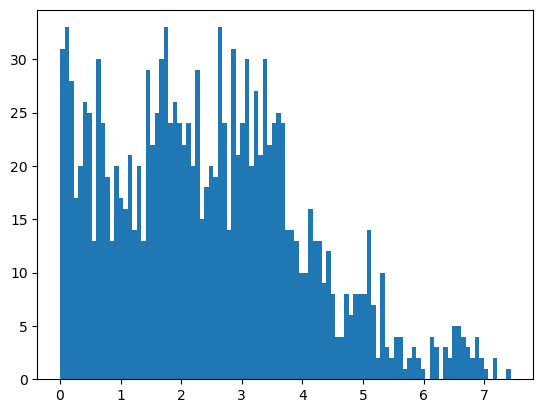

In [97]:
import matplotlib.pyplot as plt


df = df_curated 
df["band_gap"].head(4)
plt.hist(df["band_gap"], bins=100)
df

In [98]:
from ase import Atoms

def get_ase(df):
    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]
        
        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df

df = get_ase(df)
dftest = get_ase(df.head(2))
print(dftest["ase"])
print("\n test \n")
print(df["ase"])

0    (Atom('Ag', [7.484018762358994, 2.105273923157...
1    (Atom('Ag', [1.9446232162929962, -1.7475588302...
Name: ase, dtype: object

 test 

0       (Atom('Ag', [7.484018762358994, 2.105273923157...
1       (Atom('Ag', [1.9446232162929962, -1.7475588302...
2       (Atom('Ag', [2.504793, 2.504793, 0.0], index=0...
3       (Atom('Ag', [3.6893780804319993, 8.09573713852...
4       (Atom('Ag', [-2.3547247593569416e-17, 2.354724...
                              ...                        
1419    (Atom('Mg', [6.438932173827999, 1.152902882124...
1420    (Atom('Mg', [1.31771425, 5.857656804502336, 2....
1421    (Atom('Mg', [-4.8284888157376145, 2.4961544311...
1422    (Atom('Mg', [2.4679847685779963, -1.1408018649...
1423    (Atom('Mg', [3.272862736401995, 1.392418703760...
Name: ase, Length: 1424, dtype: object


/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/694997764.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ase"] = None  # Optional, for clarity


In [99]:
from dscribe.descriptors import SOAP
import numpy as np

# hier geht etwas schief die soaps vom ganze ndata set sind alle 0 

def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
    # Automatically extract all unique species from df["Elements"]
    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan 

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df

# this was an  attempt at calcualting the species lsit ofr each entry 
# def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
#     # Automatically extract all unique species from df["Elements"]

#     for i,elements in enumerate(df["Elements"]):
#         unique_species = sorted(set(elements))
#         print(unique_species)
#         # Create SOAP descriptor generator
#         soap_generator = SOAP(
#             species=unique_species,
#             r_cut=r_cut,
#             n_max=n_max,
#             l_max=l_max,
#             sigma=sigma,
#             periodic=False,
#             sparse=False
#         )
#         print(i)
#         # Generate and store SOAP descriptors
#         soap_list = []
#         for atoms in df["ase"].iloc[i]:
#             descriptor = soap_generator.create(atoms)
#             #this seems to make every soap have the same length
#             # avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan 

#             soap_list.append(descriptor)

#         df["soap"].iloc[i] = soap_list
        

#     return df


df_soap = get_soap(df)
dftest_soap = get_soap(dftest)
df_soap
df_soap.to_csv("df_soap.csv", index=False) 
df_soap_nonzero = df_soap["soap"].apply(lambda x: x.nonzero()[0])
print(df_soap_nonzero.shape)
print(df_soap.shape)

/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/3788990152.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["soap"] = soap_list


(1424,)
(1424, 6)


In [88]:
dftest_soap = get_soap(dftest)
print(dftest_soap["soap"])
print(df_soap["soap"])
dftest_soap


0    [1.2679495487354893, 0.12594177128456527, 0.04...
1    [1.2567070992865046, 0.030656087293668883, 0.0...
Name: soap, dtype: object
0       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
                              ...                        
1419    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1420    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1421    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1422    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1423    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: soap, Length: 1424, dtype: object


/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_58610/3788990152.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["soap"] = soap_list


,Elements,band_gap,positions,ratio,ase,soap
0,"[Ag, Br, S]",0.2964,"[(Ag, [7.484018762358994, 2.1052739231579953, ...",S 1 Br 1 Ag 3 dtype: int64,"(Atom('Ag', [7.484018762358994, 2.105273923157...","[1.2679495487354893, 0.12594177128456527, 0.04..."
1,"[Ag, I, S]",0.5478,"[(Ag, [1.9446232162929962, -1.7475588302039966...",S 1 I 1 Ag 3 dtype: int64,"(Atom('Ag', [1.9446232162929962, -1.7475588302...","[1.2567070992865046, 0.030656087293668883, 0.0..."


In [100]:
print(df_soap.head(2))
# df_soap.drop(columns=["ase"], inplace=True)
print(df_soap["soap"][0])

      Elements  band_gap                                          positions  \
0  [Ag, Br, S]    0.2964  [(Ag, [7.484018762358994, 2.1052739231579953, ...   
1   [Ag, I, S]    0.5478  [(Ag, [1.9446232162929962, -1.7475588302039966...   

                                  ratio  \
0  S     1
Br    1
Ag    3
dtype: int64   
1  S     1
I     1
Ag    3
dtype: int64   

                                                 ase  \
0  (Atom('Ag', [7.484018762358994, 2.105273923157...   
1  (Atom('Ag', [1.9446232162929962, -1.7475588302...   

                                                soap  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
[0. 0. 0. ... 0. 0. 0.]


In [101]:
X = np.vstack(df_soap["soap"])

# Prepare y array from the bandgaps values
y = np.hstack(df_soap["band_gap"])

print(X.shape, y.shape)
print(X)
X

(1424, 38640) (1424,)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [103]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score, RocCurveDisplay
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from scipy import stats

In [ ]:



# p_grid = {"n_estimators": [10, 15, 30], "max_depth": [None, 10, 20, 30]}

# # Initializing the Random Forest classifier
# rf = RandomForestRegressor(random_state=2)

# # Create inner and outer CV fold
# inner_cv = KFold(n_splits=5, shuffle=True, random_state=2)
# outer_cv = KFold(n_splits=5, shuffle=True, random_state=2)

# # Nested CV
# gs = GridSearchCV(estimator=rf, param_grid=p_grid, cv=inner_cv)
# nested_score = cross_val_score(gs, X=X, y=y, cv=outer_cv)
# #neg_mse_scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
# # Print accuracy and standard error of the nested CV
# print(f"Average algorithm accuracy: {np.mean(nested_score):.4f} \n"
#       f"and std err: {stats.sem(nested_score):.4f}\n")

# # Select hyperparameters with a new 5-fold CV
# gs.fit(X,y)
# print(f"Selected hyperparameters: {gs.best_params_}\n")

Average algorithm accuracy: 0.4548 
and std err: 0.0177



KeyboardInterrupt: 

In [ ]:

# ^first print done after 120min
# ^second print done after 135min
#Selected hyperparameters: {'max_depth': None, 'n_estimators': 50} mit
#p_grid = {"n_estimators": [10, 25, 50], "max_depth": [None, 10, 20, 30]}
# Average RMSE: 1.2688 	 and std err: 0.0638

In [121]:

# Parameter grid for hyperparameter search

p_grid = {"n_estimators": [50], "max_depth": [None]}
# Initialise the Random Forest classifier
rf = RandomForestRegressor(random_state=22)

# Initialise KFold
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# GridSearch CV
gs = GridSearchCV(estimator=rf, param_grid=p_grid, cv=kf)
gs.fit(X, y)
RMSE_neg = cross_val_score(gs, X=X, y=y, cv=kf, scoring='neg_mean_squared_error')
RMSE = np.sqrt(-RMSE_neg)

# Define model with best hyperparameters and print them
model = gs.best_estimator_
print(f"Hyperparameters: {gs.best_params_}\n")

#first serach returned 50 and 60 as the best paramerters with this grid
#p_grid = {"n_estimators": [40, 50,60], "max_depth": [None, 10, 20, 30,50]}
# Average RMSE: 1.2624 	 and std err: 0.0592



# 30 and 50 
# p_grid = {"n_estimators": [10, 25, 50], "max_depth": [None, 10, 20, 30]}
# Average RMSE: 1.2805 	 and std err: 0.0621


Hyperparameters: {'max_depth': None, 'n_estimators': 50}



In [122]:
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model_with_cv(model, X, y, random_state):
    """
    Evaluate a model using 5-fold cross-validation and return performance metrics.

    Parameters:
        model: The model to evaluate
        X: Feature matrix
        y: Target vector
        random_state: Random seed for reproducibility

    Returns:
        Dictionary with performance metrics and arrays of per-fold metrics
    """
    # Initialize KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    # Lists to store metrics
    metrics = {
        'RMSEs': [],
    }

    # Create figure for ROC curves
    plt.figure()

    # Iterate over folds
    for k, (train_index, test_index) in enumerate(kf.split(X)):
        # Split data
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model.predict(X_test_fold)

        # Calculate metrics
        metrics['RMSEs'].append(mean_squared_error(y_test_fold, y_pred_fold))
     

        # ROC curve

    # Print metrics
    metric_display_names = {
        'RMSEs': 'RMSE',
     
    }
    for metric_name, values in metrics.items():
        display_name = metric_display_names[metric_name]
        print(f"Average {display_name}: {np.mean(values):.4f} \t and std err: {stats.sem(values):.4f}")

    return metrics

In [123]:
metrics_rf = evaluate_model_with_cv(model, X, y, random_state=22)

Average RMSE: 1.2688 	 and std err: 0.0638


<Figure size 640x480 with 0 Axes>

In [125]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=24)

In [ ]:
rf = RandomForestRegressor(n_estimators=50, max_depth=None, random_state=22)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("MAE:", mean_absolute_error(y_val, y_pred))
print("R2:", r2_score(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))
#RMSE: 1.0720059864583598
# MAE: 0.8087310000000001
# R2: 0.529266025551792
# MSE: 1.149196835002561

RMSE: 1.0720059864583598
MAE: 0.8087310000000001
R2: 0.529266025551792
MSE: 1.149196835002561


AttributeError: 'RandomForestRegressor' object has no attribute 'summary'